In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

import warnings
warnings.filterwarnings("ignore")

## **Import dataset**

In [3]:
df = pd.read_csv("../datasets/train.csv")

## **1. Basic ds inspection**

In [4]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [5]:
df.tail()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
59395,60739,10.0,2013-05-03,Germany Republi,1210,CES,37.169807,-3.253847,Area Three Namba 27,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
59396,27263,4700.0,2011-05-07,Cefa-njombe,1212,Cefa,35.249991,-9.070629,Kwa Yahona Kuvala,0,...,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,functional
59397,37057,0.0,2011-04-11,NaN,0,NaN,34.017087,-8.750434,Mashine,0,...,fluoride,fluoride,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,functional
59398,31282,0.0,2011-03-08,Malec,0,Musa,35.861315,-6.378573,Mshoro,0,...,soft,good,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,functional
59399,26348,0.0,2011-03-23,World Bank,191,World,38.104048,-6.747464,Kwa Mzee Lugawa,0,...,salty,salty,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump,functional


In [6]:
df.shape

(59400, 41)

In [7]:
df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  str    
 3   funder                 55763 non-null  str    
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  str    
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  str    
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  str    
 11  subvillage             59029 non-null  str    
 12  region                 59400 non-null  str    
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lga          

In [9]:
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [10]:
df.describe(include='object')

,date_recorded,funder,installer,wpt_name,basin,subvillage,region,lga,ward,public_meeting,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
count,59400,55763,55745,59398,59400,59029,59400,59400,59400,56066,...,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400
unique,356,1896,2145,37399,9,19287,21,125,2092,2,...,8,6,5,5,10,7,3,7,6,3
top,2011-03-15,Government Of Tanzania,DWE,none,Lake Victoria,Madukani,Iringa,Njombe,Igosi,True,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
freq,572,9084,17402,3563,10248,508,5294,2503,307,51011,...,50818,50818,33186,33186,17021,17021,45794,28522,34625,32259


## **2. Zero-Value Analysis**

In [38]:
zero_data = []

for col in df.select_dtypes(include=np.number).columns:

    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100

    if zeros > 0:
        zero_data.append([col, zeros, pct])

# Convert to DataFrame
zero_df = pd.DataFrame(
    zero_data,
    columns=['Column', 'Zero Count', 'Percentage']
)

# Sort descending
zero_df = zero_df.sort_values(
    by='Zero Count',
    ascending=False
)

print(zero_df)

              Column  Zero Count  Percentage
4        num_private       58643   98.725589
1         amount_tsh       41639   70.099327
6         population       21381   35.994949
7  construction_year       20709   34.863636
2         gps_height       20438   34.407407
3          longitude        1812    3.050505
5      district_code          23    0.038721
0                 id           1    0.001684


# `Comments`
### `Fix implicit missing` (zeros → NaN then impute with region median):

- construction_year — 34.9% are zeros, not real values
- population — 36% zeros, not real values
- gps_height — 34.4% zeros, can't be at sea level
- amount_tsh — 70.1% zeros, clearly missing not real

### `drop Columns:`
- `num_private` bec 99% of it has zeros

### `changes:`
- `onstruction_year`, `population` and `gps_height` need to change zeros to NaN values bec they will affect our reading of data, then we can decide how to replace these NaN values like with mean, mode or median and etc,




## **3. Missing Values Analysis**

In [11]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

missing_df.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
scheme_name,28810,48.501684
scheme_management,3878,6.528620
installer,3655,6.153199
funder,3637,6.122896
public_meeting,3334,5.612795
permit,3056,5.144781
subvillage,371,0.624579
wpt_name,2,0.003367
id,0,0.000000
latitude,0,0.000000


# `Comments`
### `Drop:`
- `scheme_name` as it contains 48.5% NaN values

### `Modification:`
`funder`, `installer`, `scheme_management`, `public_meeting`, `permit` — 5–6% missing, fill with mode or "Unknown" 

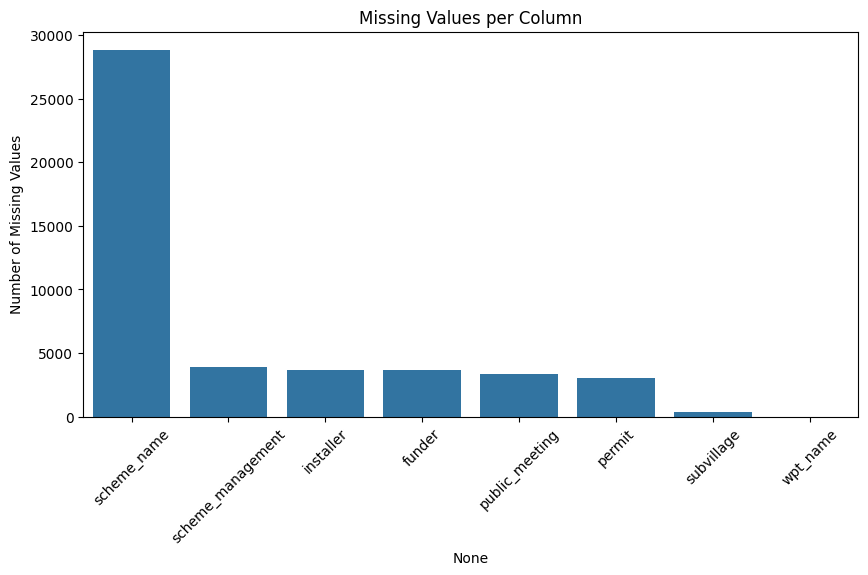

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Missing values count
missing = df.isnull().sum()

# Keep only columns with missing values
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.xticks(rotation=45)
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column")

plt.show()

## **4. Duplicate Analysis**

In [14]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df['id'].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


## **5. Target Variable Analysis**

In [75]:
print(df['status_group'].value_counts())

df['status_group'].value_counts(normalize=True) * 100

status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64


status_group
functional                 54.308081
non functional             38.424242
functional needs repair     7.267677
Name: proportion, dtype: float64

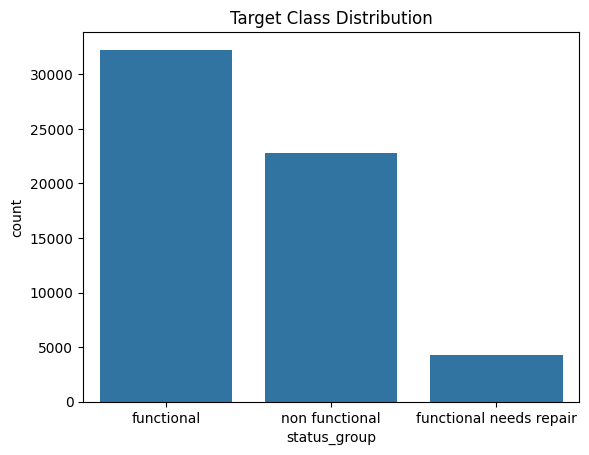

In [16]:
sns.countplot(x='status_group', data=df)
plt.title("Target Class Distribution")
plt.xticks()
plt.show()

# `Comments`
`Class imbalance:`
Because the target has 32259 functional vs 4317 needs repair. Without telling the model about this, it will just predict "functional" for everything and still get 54% accuracy while completely ignoring the minority class. 

`Suggestions:`
class_weight='balanced' forces the model to pay more attention to rare classes.

## Separate numerical columns

In [50]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols = [c for c in num_cols if c != 'id']
print("\n### NUMERICAL COLUMNS ###")
print(num_cols)


### NUMERICAL COLUMNS ###
['amount_tsh', 'gps_height', 'longitude', 'latitude', 'num_private', 'region_code', 'district_code', 'population', 'construction_year', 'year_recorded', 'month_recorded']


## **6. Descriptive Statistics**

In [48]:
stats_df = pd.DataFrame()

stats_df['Mean'] = df[num_cols].mean()
stats_df['Median'] = df[num_cols].median()
stats_df['Mode'] = df[num_cols].mode().iloc[0]
stats_df['Std'] = df[num_cols].std()
stats_df['Variance'] = df[num_cols].var()
stats_df['Skewness'] = df[num_cols].skew()
stats_df['Kurtosis'] = df[num_cols].kurt()

stats_df.round(3)


,Mean,Median,Mode,Std,Variance,Skewness,Kurtosis
amount_tsh,317.650,0.000,0.0,2997.575,8985453.232,57.808,4903.543
gps_height,668.297,369.000,0.0,693.116,480410.275,0.462,-1.292
longitude,34.077,34.909,0.0,6.567,43.131,-4.191,19.187
latitude,-5.706,-5.022,-0.0,2.946,8.679,-0.152,-1.058
num_private,0.474,0.000,0.0,12.236,149.725,91.934,11137.295
region_code,15.297,12.000,11.0,17.587,309.317,3.174,10.288
district_code,5.630,3.000,1.0,9.634,92.807,3.962,16.214
population,179.910,25.000,0.0,471.482,222295.442,12.661,402.280
construction_year,1300.652,1986.000,0.0,951.621,905581.666,-0.635,-1.596


# `Comments`
Transform (log1p):
- `amount_tsh` - skewness 57.8, kurtosis 4903
- `population` - skewness 12.7, kurtosis 402
- `num_private` - skewness 91.9. kurtosis 11137

## **7. Distribution Plots** `(each two for same feature)`

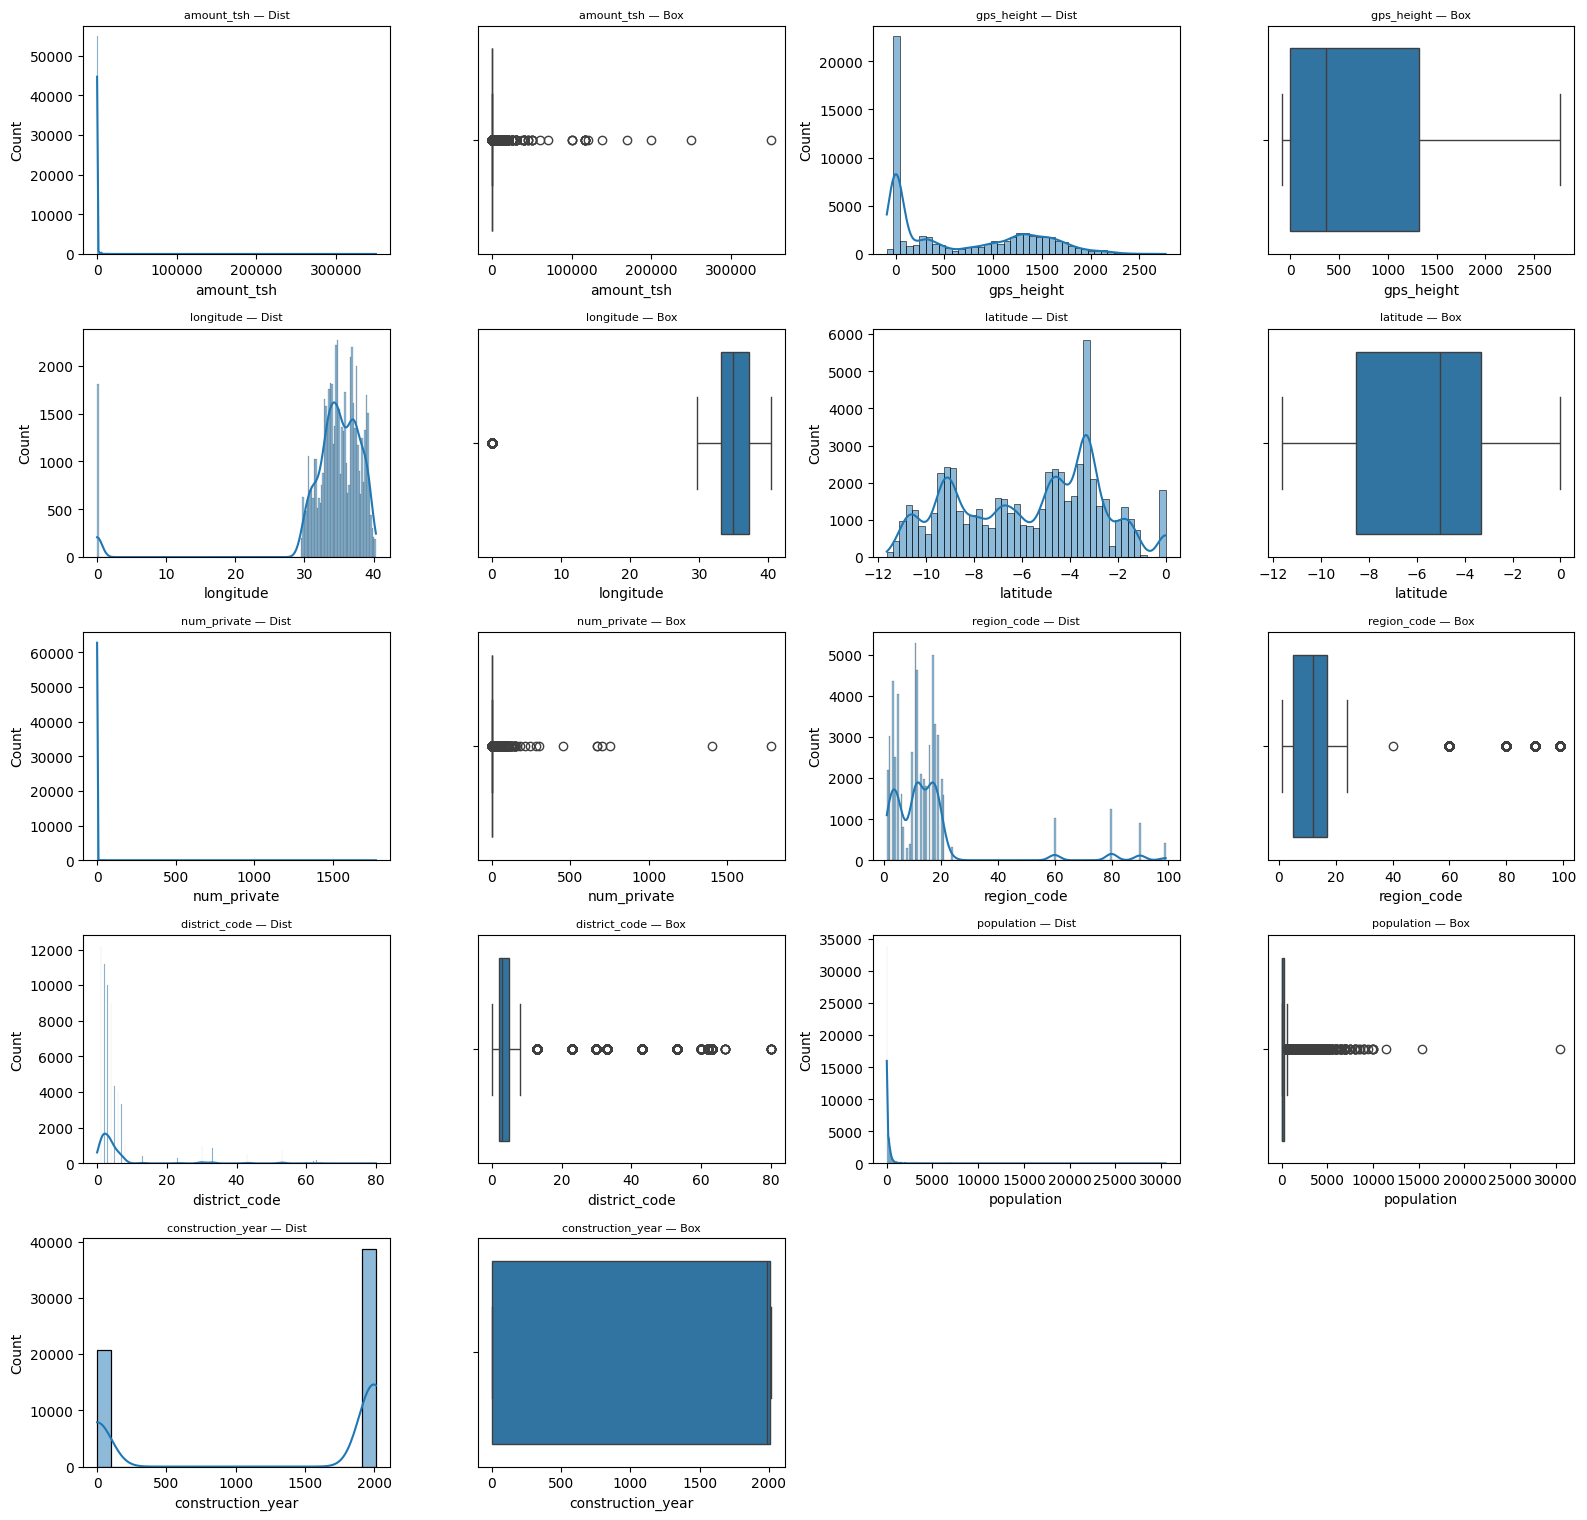

In [19]:
cols_per_row = 2  
n_rows = len(num_cols)  

plt.figure(figsize=(16, n_rows * 3))

for i, col in enumerate(num_cols):
    row = (i // cols_per_row) * 2  
    pos_in_row = i % cols_per_row  

    # histogram
    plt.subplot(n_rows, 4, (i // 2) * 4 + (pos_in_row * 2) + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} — Dist", fontsize=8)

    # boxplot
    plt.subplot(n_rows, 4, (i // 2) * 4 + (pos_in_row * 2) + 2)
    sns.boxplot(x=df[col])
    plt.title(f"{col} — Box", fontsize=8)

plt.tight_layout()
plt.show()

# `Comments`
`amount_tsh`, `construction_year` have lots of zeros that needs to be replaced

## **8. Outlier Detection**

In [51]:
print("\n### OUTLIERS ###")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")


### OUTLIERS ###
amount_tsh: 11161 outliers (18.8%)
gps_height: 0 outliers (0.0%)
longitude: 1812 outliers (3.1%)
latitude: 0 outliers (0.0%)
num_private: 757 outliers (1.3%)
region_code: 3604 outliers (6.1%)
district_code: 4188 outliers (7.1%)
population: 4383 outliers (7.4%)
construction_year: 0 outliers (0.0%)
year_recorded: 31 outliers (0.1%)
month_recorded: 0 outliers (0.0%)


## **9. Unique Values Analysis**

In [64]:
df.nunique().sort_values(ascending=False)

id                       59400
latitude                 57517
longitude                57516
wpt_name                 37399
subvillage               19287
scheme_name               2695
gps_height                2428
installer                 2145
ward                      2092
funder                    1896
population                1049
date_recorded              356
lga                        125
amount_tsh                  98
num_private                 65
construction_year           55
region_code                 27
region                      21
district_code               20
extraction_type             18
extraction_type_group       13
month_recorded              12
management                  12
scheme_management           11
source                      10
basin                        9
water_quality                8
source_type                  7
waterpoint_type              7
payment_type                 7
extraction_type_class        7
payment                      7
waterpoi

# `Comments`
columns that needs to be dropped:
- `id` - just an index, doesn't affect anything
- `recorded_by` - 1 unique value across all rows
- `wpt_name`, `subvillage`, `ward`, `scheme_name` --2k-37k unique value as they will be unlearnable

## **10. Categorical Features Analysis**

In [58]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(df[col].value_counts())


funder
Government Of Tanzania    9084
Danida                    3114
Hesawa                    2202
Rwssp                     1374
World Bank                1349
                          ... 
Cida                         1
Dwe/anglican Church          1
Dina                         1
Brown                        1
Samlo                        1
Name: count, Length: 1896, dtype: int64
installer
DWE                    17402
Government              1825
RWE                     1206
Commu                   1060
DANIDA                  1050
                       ...  
DWE/Anglican church        1
VIFAI                      1
Dina                       1
brown                      1
SELEPTA                    1
Name: count, Length: 2145, dtype: int64
wpt_name
none                   3563
Shuleni                1748
Zahanati                830
Msikitini               535
Kanisani                323
                       ... 
Chimeredya                1
Area Three Namba 27       1
Kwa Yahona

# `Comments`
by comparing values and counts we can identify the following:

| Column | identical/redundant to |
|--------|--------|
| `quantity_group` | Identical to `quantity` |
| `payment_type` | Identical to `payment` |
| `quality_group` | Identical to `water_quality` |
| `source_type` | Redundant with `source_class` |
| `waterpoint_type_group` | Redundant with `waterpoint_type` |
| `management_group` | Redundant with `management` |
| `extraction_type_group` | Redundant with `extraction_type_class` |

Danida and Danid

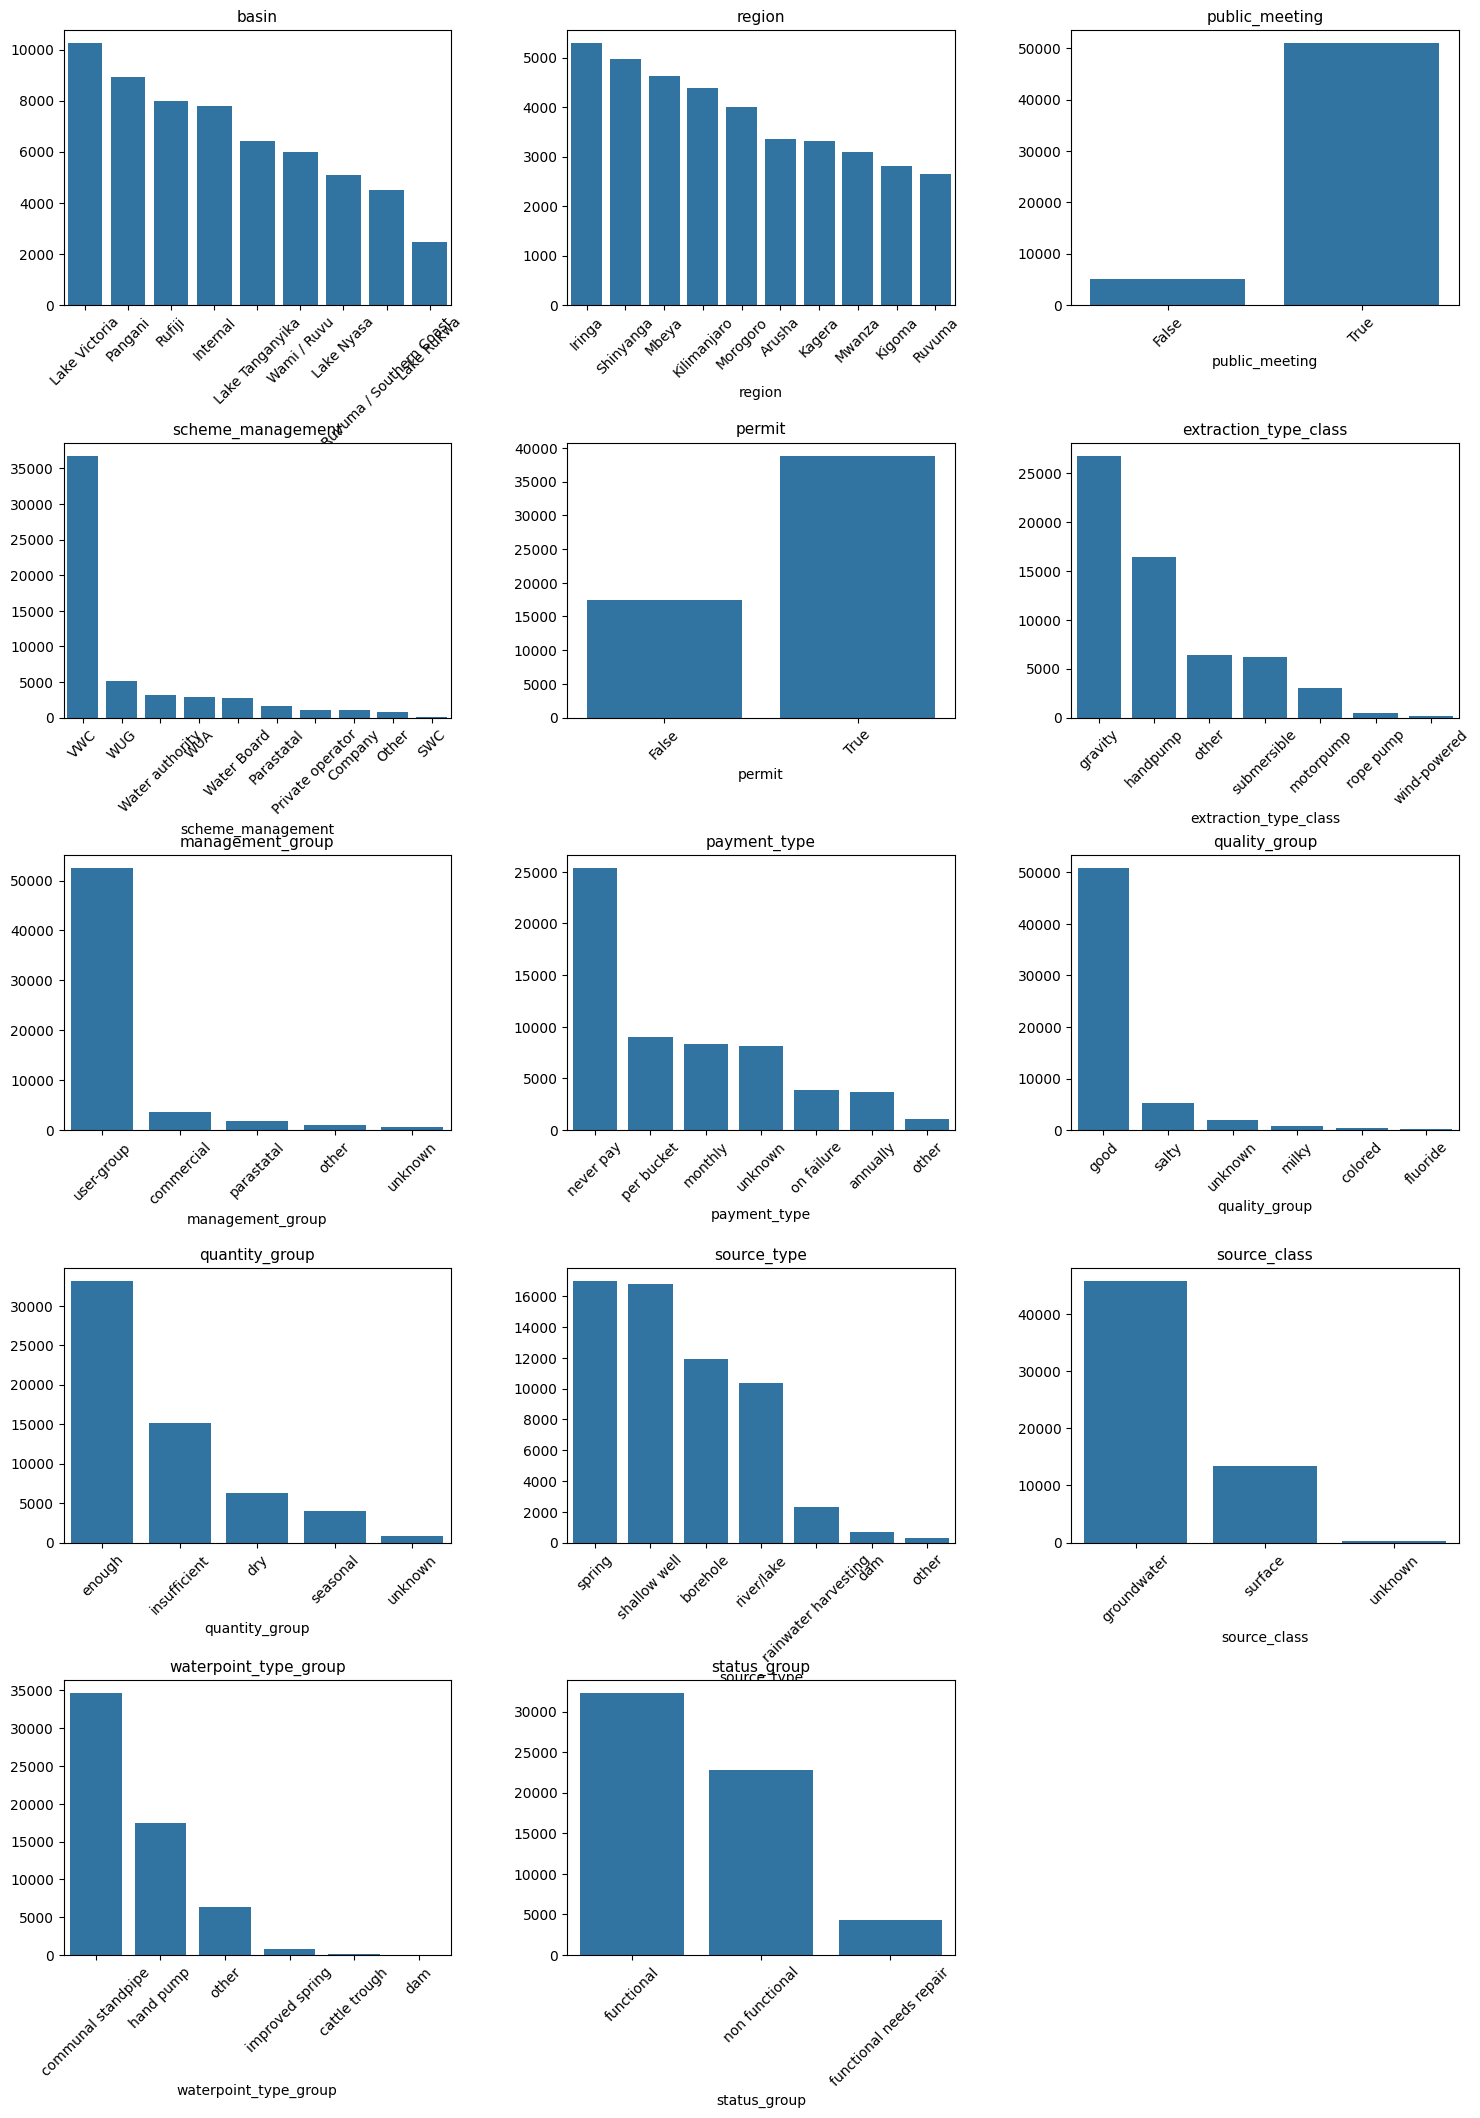

In [60]:
important_cat_cols = [
    'basin',
    'region',
    'public_meeting',
    'scheme_management',
    'permit',
    'extraction_type_class',
    'management_group',
    'payment_type',
    'quality_group',
    'quantity_group',
    'source_type',
    'source_class',
    'waterpoint_type_group',
    'status_group'
]

cols = 3
rows = (len(important_cat_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))

axes = axes.flatten()

for i, col in enumerate(important_cat_cols):

    top_categories = df[col].value_counts().iloc[:10]

    sns.barplot(
        x=top_categories.index,
        y=top_categories.values,
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=11)

    axes[i].tick_params(axis='x', rotation=45)

# Hide empty plots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.subplots_adjust(
    hspace=0.5,
    wspace=0.3
)

plt.show()

## **11. Correlation Analysis**

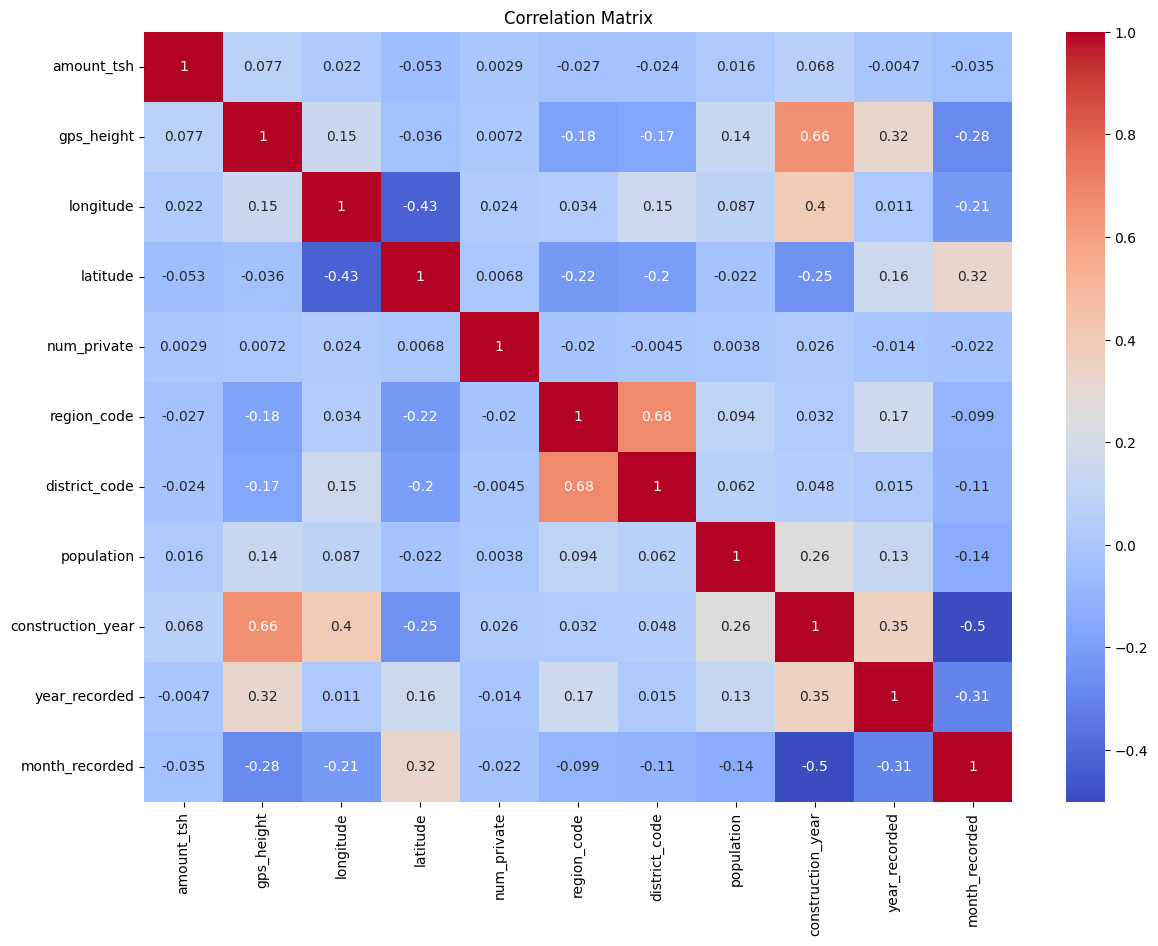

In [54]:
corr = df[num_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### `Date-time` msh mohema kont bgrab 7aga w msh 3ayz ams7ha 3lshan el year graph el fo2 kan shaklo we7sh -_-


### RECORDING YEAR DISTRIBUTION ###
year_recorded
2002        1
2004       30
2011    28674
2012     6424
2013    24271
Name: count, dtype: int64


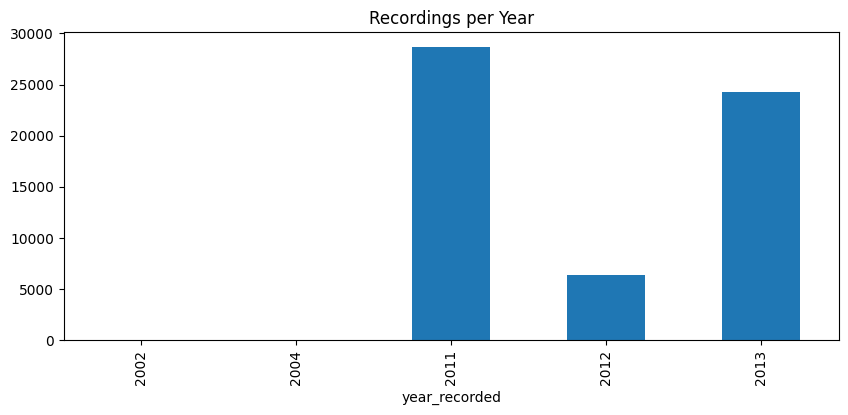

In [55]:
df['date_recorded'] = pd.to_datetime(df['date_recorded'])
df['year_recorded']  = df['date_recorded'].dt.year
df['month_recorded'] = df['date_recorded'].dt.month
 
print("\n### RECORDING YEAR DISTRIBUTION ###")
print(df['year_recorded'].value_counts().sort_index())
 
df['year_recorded'].value_counts().sort_index().plot(kind='bar', figsize=(10, 4))
plt.title("Recordings per Year")
plt.show()

# `Comments`
a7san mn el fo2


## **12. Feature vs Target Analysis**

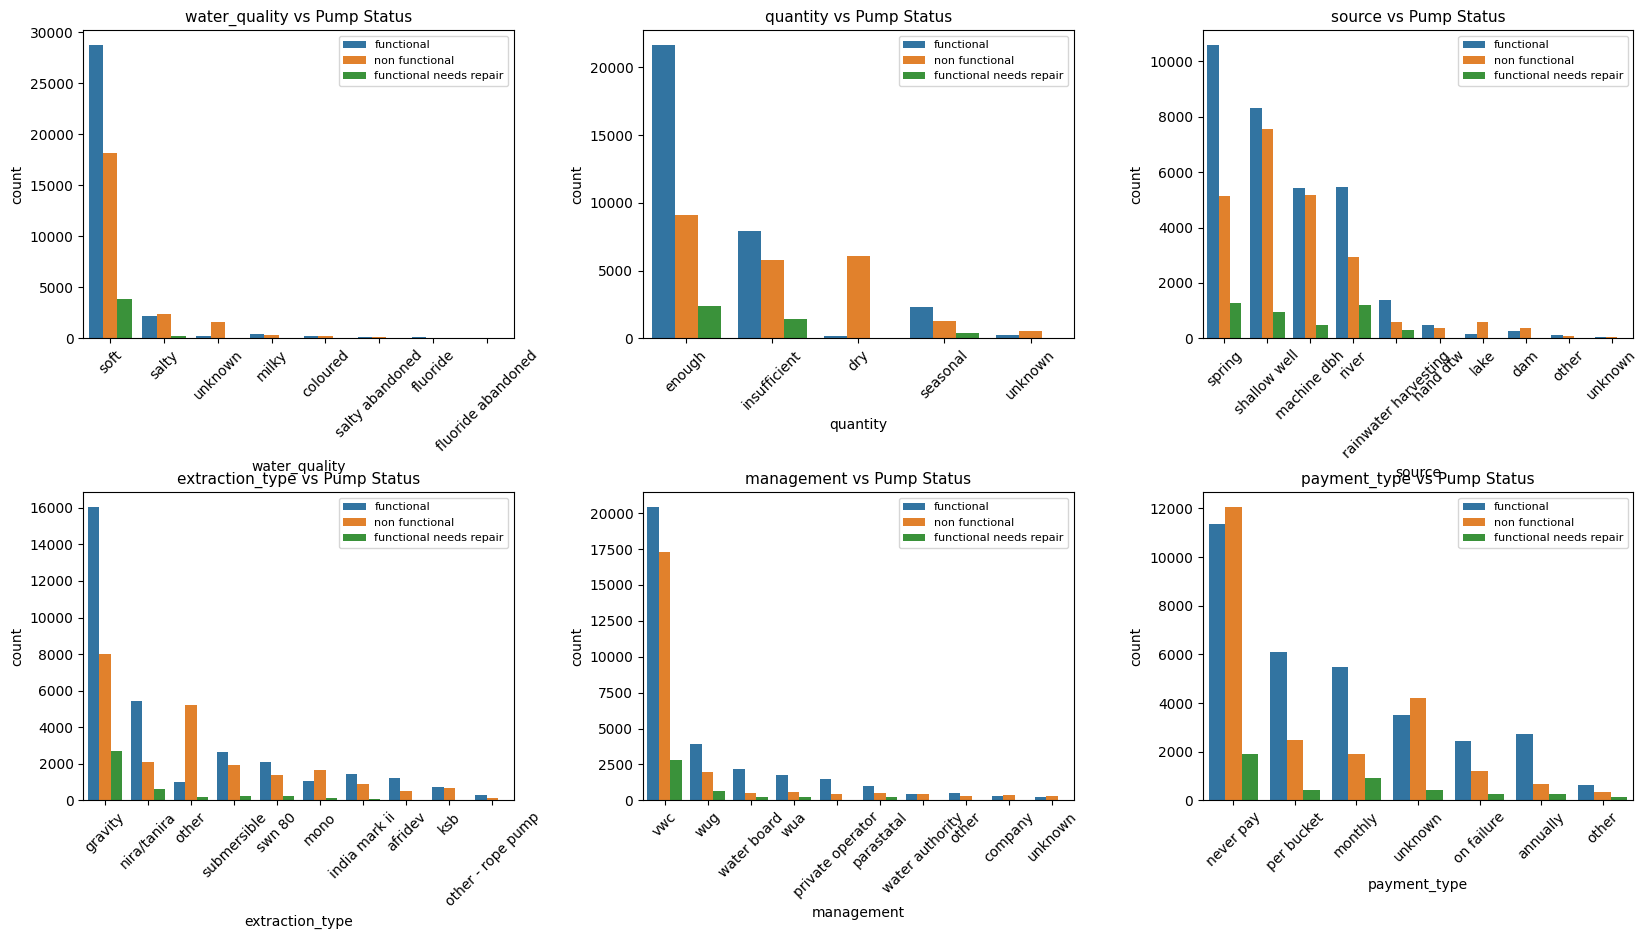

In [33]:
important_features = [
    'water_quality',
    'quantity',
    'source',
    'extraction_type',
    'management',
    'payment_type'
]

cols = 3
rows = (len(important_features) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5))

axes = axes.flatten()

for i, col in enumerate(important_features):

    if col in df.columns:

        sns.countplot(
            x=col,
            hue='status_group',
            data=df,
            ax=axes[i],
            order=df[col].value_counts().iloc[:10].index
        )

        axes[i].set_title(f"{col} vs Pump Status", fontsize=11)

        axes[i].tick_params(axis='x', rotation=45)

        axes[i].legend(fontsize=8)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.subplots_adjust(
    hspace=0.5,
    wspace=0.3
)

plt.show()

# `Comments`
`High predictive signal:`

- `quantity` - dry pumps are 96.9% non-functional
- `payment_type` - pumps with payment are far more functional
- `waterpoint_type` - "other" type is 82.2% non-functional
- `management` - private/water board managed pumps are much more functional
- `extraction_type_class` - clear differences across classes
- `water_quality` - unknown quality = 84.1% non-functional
- `source_class` - good signal with only 3 categories

## **13. Construction Year Problems**
You will probably notice:

0 values
unrealistic years which is major preprocessing issue.

In [74]:
print("\n### CONSTRUCTION YEAR ###")
print("Year == 0:", (df['construction_year'] == 0).sum())
print(df['construction_year'].value_counts().sort_index().head(20))


### CONSTRUCTION YEAR ###
Year == 0: 20709
construction_year
0       20709
1960      102
1961       21
1962       30
1963       85
1964       40
1965       19
1966       17
1967       88
1968       77
1969       59
1970      411
1971      145
1972      708
1973      184
1974      676
1975      437
1976      414
1977      202
1978     1037
Name: count, dtype: int64


## *14. 7agat chatgpt 2aly azawedha but I tried to afham men dool*
### *(we might need them)*

### `1. Geographic Analysis`
**el fekra hna an we can make new feature (Coordinates) mn longitude w latitude 3lshan n3rf el position bzbt so we can use el coordinates 3la tool or smth**

IMPORTANT because dataset contains:

latitude
longitude
basin
region

Check:

invalid coordinates
zero coordinates

This dataset commonly has longitude = 0 issues.


### GEOGRAPHIC ISSUES ###
longitude == 0: 1812
latitude  == 0: 0


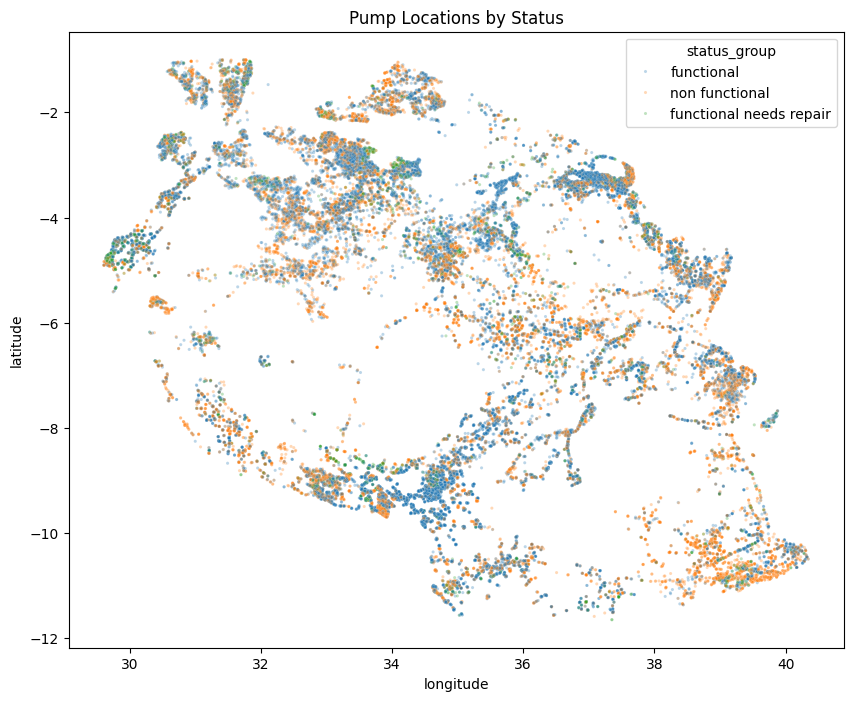

In [27]:
print("\n### GEOGRAPHIC ISSUES ###")
print("longitude == 0:", (df['longitude'] == 0).sum())
print("latitude  == 0:", (df['latitude']  == 0).sum())
 
geo = df[(df['longitude'] != 0) & (df['latitude'] != 0)]
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='status_group',
                data=geo, alpha=0.3, s=5)
plt.title("Pump Locations by Status")
plt.show()

# ============================================================
# A5yran 5laaaaaaaaaaaaaaaaaast, My Finallllllll conclusion
# ============================================================
this is based 3n el analysis wel comments el fl nos w kman I skimmed through el dataset 

## Dataset Overview
- 59,400 rows × 43 columns
- 9 numerical, 29 categorical, 1 target
- No duplicate rows or IDs
- Target: 3 classes (functional / non functional / functional needs repair)

---

## Target Variable
- functional: 54.3% — non functional: 38.4% — needs repair: 7.3%
- **Fix:** use `class_weight='balanced'` in the model so it doesn't ignore the minority class

---

## Columns to Drop
| Column | Reason |
|--------|--------|
| `id` | Just a row index, mantky sara7a ytshal |
| `recorded_by` | Only 1 unique value across all 59,400 rows |
| `num_private` | 98.7% zeros, no useful information |
| `scheme_name` | 48.5% missing, too high to impute |
| `wpt_name` | 37,399 unique values, unlearnable |
| `subvillage` | 19,287 unique values |
| `ward` | 2,092 unique values, too granular |
| `quantity_group` | Identical to `quantity` |
| `payment_type` | Identical to `payment` |
| `quality_group` | Identical to `water_quality` |
| `source_type` | Redundant with `source_class` |
| `waterpoint_type_group` | Redundant with `waterpoint_type` |
| `management_group` | Redundant with `management` |
| `extraction_type_group` | Redundant with `extraction_type_class` |

---

## Missing Values to Fix
| Column | Issue | Fix |
|--------|-------|-----|
| `amount_tsh` | 70.1% zeros = missing | I think we should remove it but not sure |
| `construction_year` | 34.9% zeros = missing | Replace 0 with NaN → fill with median |
| `population` | 36% zeros = missing | Replace 0 with NaN → fill with median |
| `gps_height` | 34.4% zeros = missing | Replace 0 with NaN → fill with median |
| `longitude` | 3.1% zeros = impossible | Replace 0 with NaN → fill with median |
| `funder` | 6.1% NaN | Fill with "Unknown" |
| `installer` | 6.1% NaN | Fill with "Unknown" |
| `scheme_management` | 6.5% NaN | Fill with mode |
| `public_meeting` | 5.6% NaN | Fill with mode |
| `permit` | 5.1% NaN | Fill with mode |

---

## Skewness & Outliers
| Column | Skewness | Kurtosis | Fix |
|--------|----------|----------|-----|
| `amount_tsh` | 57.8 | 4903.5 | log1p transform |
| `population` | 12.7 | 402.3 | log1p transform |
| `longitude` | -4.2 | 19.2 | I don't know if there is a problem here or no but the kurtosis is still high!! |
| `num_private` | 91.9 | 11137.3 | Drop entirely |

---

# some Suggestions to add
## Feature Engineering (New Columns we can add)
| New Column | Formula | Why |
|------------|---------|-----|
| `pump_age` | `year_recorded - construction_year` | Older pumps more likely to fail |
| `is_year_missing` | `1 if construction_year == 0` | Tell model where year was missing |
| `is_pop_missing` | `1 if population == 0` | Tell model where population was missing |
| `is_coord_missing` | `1 if longitude == 0` | Tell model where coordinates were invalid |

---

## Most Important Features for Modeling
Based on crosstab analysis, these features show the strongest relationship with pump status:

| Feature | Why It Matters |
|---------|---------------|
| `quantity` | Dry pumps are mostly non-functional|
| `payment` | Pumps with payment plans are far more functional|
| `waterpoint_type` | "Other" type is mostly non-functional |
| `management` | Private/water board managed = much higher functionality |
| `water_quality` | Unknown quality are mostly non-functional |
| `extraction_type_class` | Clear functionality differences across extraction methods |
| `source_class` | Only 3 categories |
| `pump_age` | Engineered — age of pump predicts failure |
| `gps_height` | Correlates with geography and construction era |